In [3]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from functions import Functions

pfns = PlottingFns()
fns = Functions()


In [5]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [6]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [7]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [8]:
extent = [138, 150,-68,-64]
extent_tt = [116,122,-67.5,-63]
extent_vc = [105,111,-67,-64]
extent_pb = [67,82,-70,-66]

mertz = Region('Mertz',extent)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [9]:
dscli = xr.open_dataset(fname_zhou)
dscli = dscli.squeeze().rename({'lat':'latitude','lon':'longitude','prs':'pressure'}) \
    .swap_dims({'NB_y':'latitude','NB_x':'longitude','NB_LEV':'pressure'})
dscli = fns.crop_to_extent(dscli,extent)
dscli['sigma0'] = gsw.density.sigma0(dscli.sa,dscli.ct)



In [10]:
ds = pickle.load(open('c3data.pkl','rb'))

In [11]:
n_min = 10
mon_mean = ds.resample({'time':'MS'}).mean()
mon_count = ds.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean = mon_mean.where(mon_count > n_min, drop=True)

In [12]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons

seasons = get_seasons(ds)



In [13]:
dscli

<xarray.Dataset> Size: 45MB
Dimensions:    (pressure: 601, longitude: 61, latitude: 31)
Coordinates:
  * pressure   (pressure) float64 5kB 5.0 15.0 25.0 ... 5.995e+03 6.005e+03
  * longitude  (longitude) float64 488B 138.0 138.2 138.4 ... 149.6 149.8 150.0
  * latitude   (latitude) float64 248B -68.0 -67.9 -67.8 ... -65.2 -65.1 -65.0
Data variables:
    ct         (pressure, longitude, latitude) float64 9MB nan nan ... nan nan
    sa         (pressure, longitude, latitude) float64 9MB nan nan ... nan nan
    ct_mse     (pressure, longitude, latitude) float64 9MB nan nan ... nan nan
    sa_mse     (pressure, longitude, latitude) float64 9MB nan nan ... nan nan
    sigma0     (pressure, longitude, latitude) float64 9MB nan nan ... nan nan

In [14]:
# plotting function for seasonal on/off-shelf profiles
def plot_var(ax,var,title,c,ylim):
    for i,s in enumerate(seasons):
        #get onslope profile
        data=seasons[s].where(seasons[s].elevation > -1000,drop=True)[var]
        data=data.where(data.count('time') > 10, drop=True).mean('time')
        ax.plot(data,data.pres,'-',c=c[i],label=s + ' on-shelf')
        #get offslope profile
        data=seasons[s].where(seasons[s].elevation < -1000,drop=True)[var]
        data=data.where(data.count('time') > 10, drop=True).mean('time')
        ax.plot(data,data.pres,'--',c=c[i],label=s+' off-shelf')
    ax.invert_yaxis()
    ax.set_xlim(ylim)
    ax.set_xlabel(title)
    ax.set_ylabel('Pressure/dbar')
    ax.legend(loc='lower left')

# plotting function for climatolgy
clim_139E = dscli.where(dscli.longitude==145,drop=True).squeeze()
def plot_clim(ax,var,title,cmap):
    im=ax.contourf(clim_139E.latitude,clim_139E.pressure,clim_139E[var],cmap=cmap,levels=40)
    ax.plot(elevation.latitude,-elevation.sel(longitude=145,method='nearest'))
    ax.set_ylim([0,1000])
    ax.set_xlim([-67.1,-65])
    ax.set_ylabel('Pressure/dbar')
    ax.set_xlabel('Latitude')
    #ax.set_yscale('log')
    ax.yaxis.set_inverted(True)

    cbar = plt.colorbar(im)
    cbar.set_label(title)

KeyError: "No variable named 'sigma0'. Variables on the dataset include ['temp', 'psal', 'dsource', 'mld', 'asal', ..., 'time', 'pres', 'lon', 'lat', 'n_prof']"

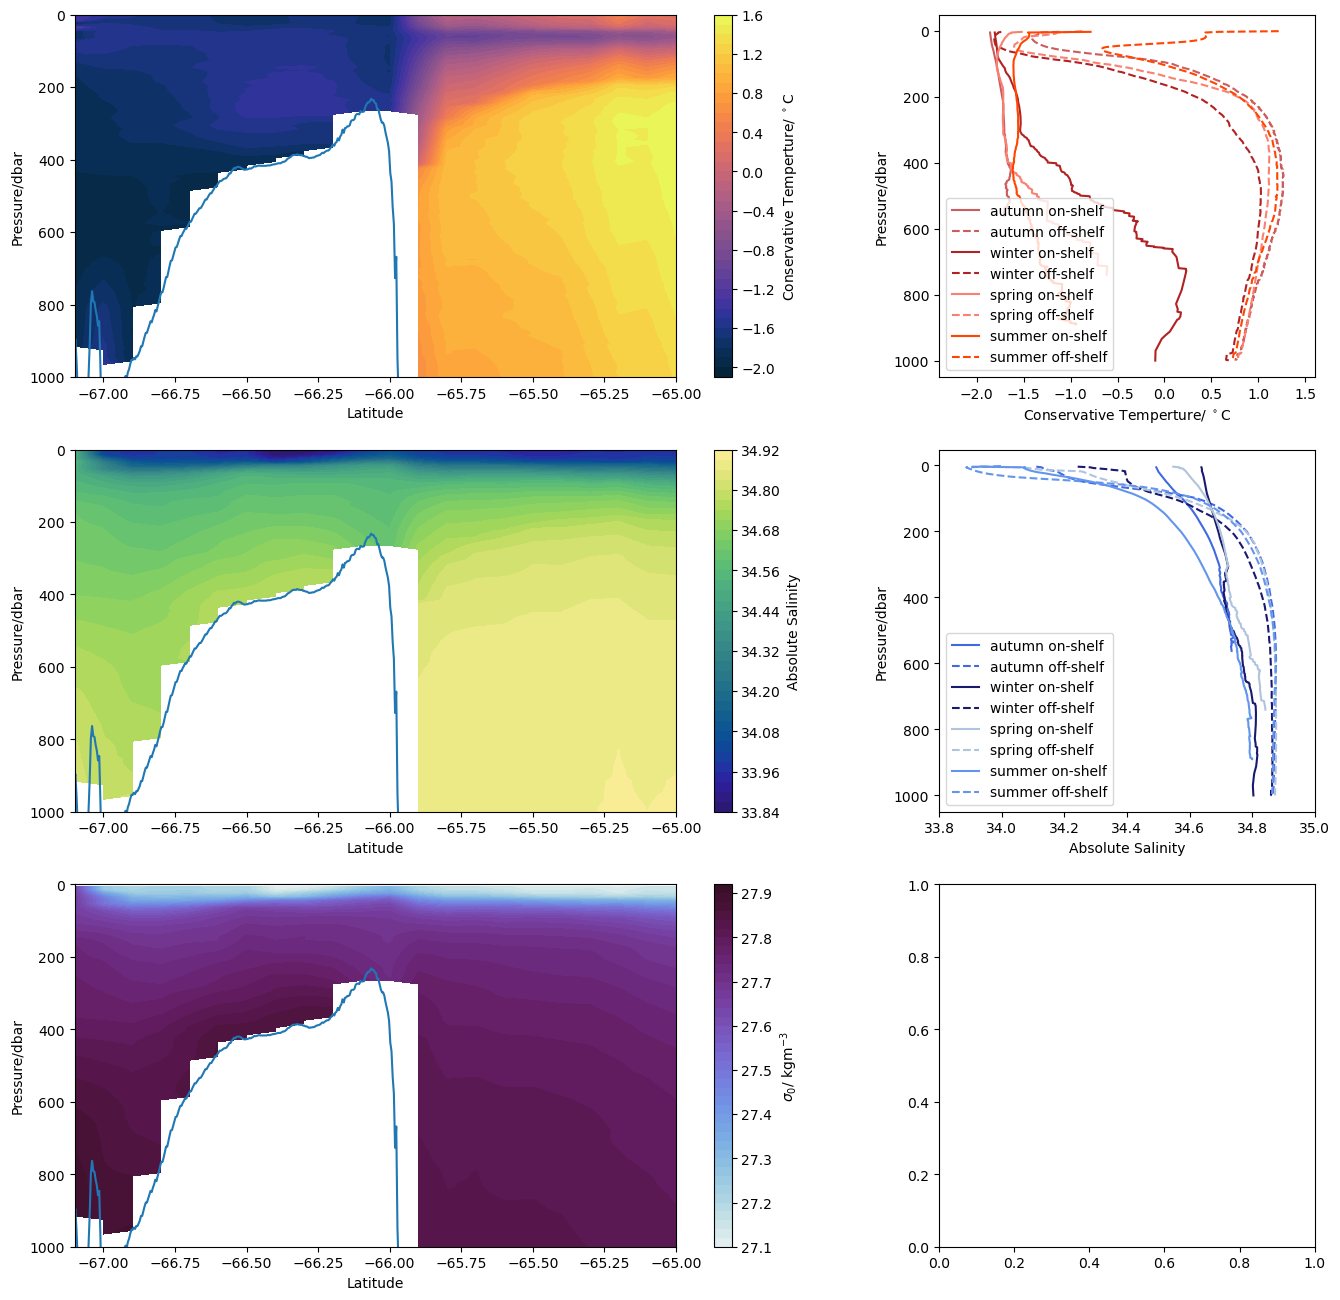

In [15]:
fig, axs = plt.subplots(3,2,figsize=(16,16),width_ratios=[2,1])

# 1st row: temperture
ax=axs[0]
lbl = r'Conservative Temperture/ $^\circ$C'
plot_clim(ax[0],'ct',lbl,cmocean.cm.thermal)
plot_var(ax[1],'ctemp',lbl,['indianred','firebrick','salmon','orangered'],[-2.4,1.6])

# 2nd row: salinity
ax=axs[1]
plot_clim(ax[0],'sa','Absolute Salinity',cmocean.cm.haline)
plot_var(ax[1],'asal','Absolute Salinity',['royalblue','midnightblue','lightsteelblue','cornflowerblue'],[33.8,35])


#3rdr row: density
ax=axs[2]
lbl = r'$\sigma_0$/ kgm$^{-3}$'
plot_clim(ax[0],'sigma0',lbl,cmocean.cm.dense)
plot_var(ax[1],'sigma0',lbl,['mediumvioletred','darkmagenta','plum','violet'],[27,27.9])


plt.tight_layout()

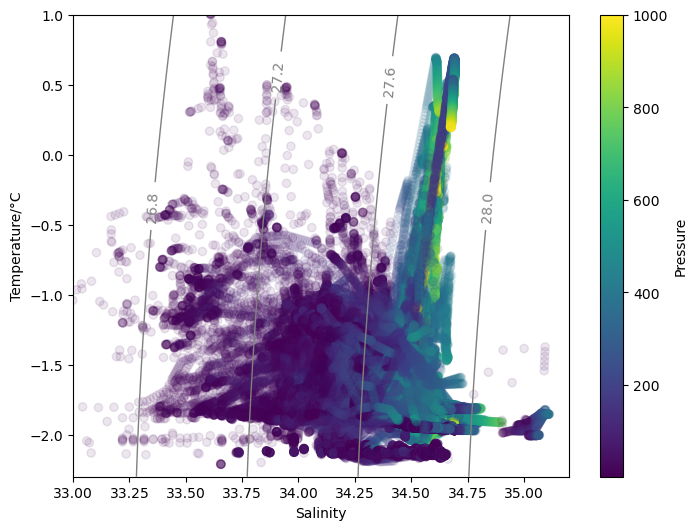

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
# shapes=['o','s','*','D']
# for s,c in zip(seasons,shapes):
im=ax.scatter(ds_shelf.psal,ds_shelf.temp,alpha=0.05,c=ds_shelf.pres.broadcast_like(ds_shelf.time))

tlim=[-2.3,1]
slim=[33,35.2]
temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
ax.set_xlim(slim)
ax.set_ylim(tlim)
ax.set_ylabel('Temperature/°C')
ax.set_xlabel('Salinity')

im.set_alpha(1)          # make colorbar opaque
bar=plt.colorbar(im)
im.set_alpha(0.1)

bar.set_label('Pressure')

In [ ]:
#find seals which travel a decent (>1 degree) meridional distance
mdlmax = ds.reset_coords().groupby('profile_code').max().lat
mdlmin = ds.reset_coords().groupby('profile_code').min().lat
mdemax = ds.reset_coords().groupby('profile_code').max().elevation
mdemin= ds.reset_coords().groupby('profile_code').min().elevation

longg = mdlmax.time.where(((mdlmax - mdlmin) > 0.6) & ((mdemax - mdemin) > 800), drop=True)

In [15]:
longg

<xarray.DataArray 'profile_code' (profile_code: 2)> Size: 16B
array(['ft33-791-22', 'wd20-546-19'], dtype=object)
Coordinates:
  * profile_code  (profile_code) object 16B 'ft33-791-22' 'wd20-546-19'

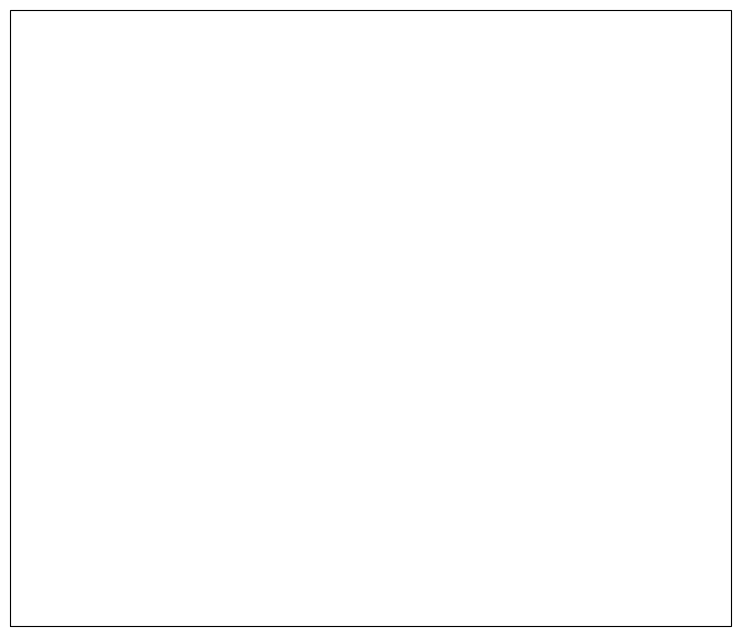

In [16]:
pc = longg[0]
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.Mercator()})
# pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
# for platform in longg:
#     dff = ds.where(ds.profile_code == platform,drop=True)
#     ax.scatter(dff.lon,dff.lat,transform=ccrs.PlateCarree(),label=platform.item())
# ax.legend()

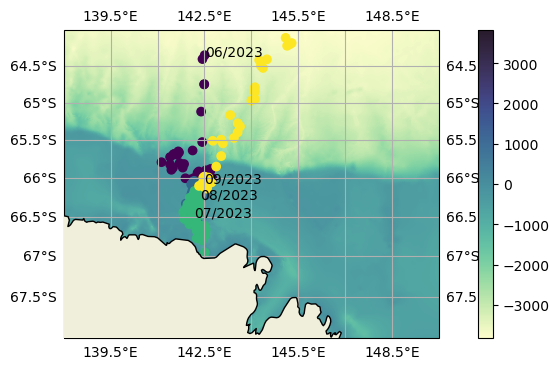

In [40]:
pc = longg[0].item() #'ct84-744-12'#'ct64-M052-09'#'ft33-791-22'
dspc = ds.where(ds.profile_code == pc,drop=True)
fig,ax=plt.subplots(figsize=(10,4),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep)
ax.scatter(dspc.lon,dspc.lat,c=dspc.month.sel(pres=0),transform=ccrs.PlateCarree(),label=pc)
for m in np.unique(dspc.month):
    eg = dspc.where(dspc.month==m,drop=True).isel(time=0)
    tstr = eg.time.dt.strftime("%m/%Y").item()
    ax.text(eg.lon,eg.lat,tstr,transform=ccrs.PlateCarree())
plt.colorbar(im)

In [44]:
dsm = dspc.where((dspc.month == 9) | (dspc.month == 8),drop=True)
dsml = dsm.swap_dims({'time':'lat'}).sortby('lat')
keep = ~(np.isnan(dsml.sigma0))
x=xr.broadcast(dsml.lat,dsml.pres)[0].where(keep,drop=True).to_numpy().flatten()
y=xr.broadcast(dsml.lat,dsml.pres)[1].where(keep,drop=True).to_numpy().flatten()

Text(0.5, 1.0, 'potential density')

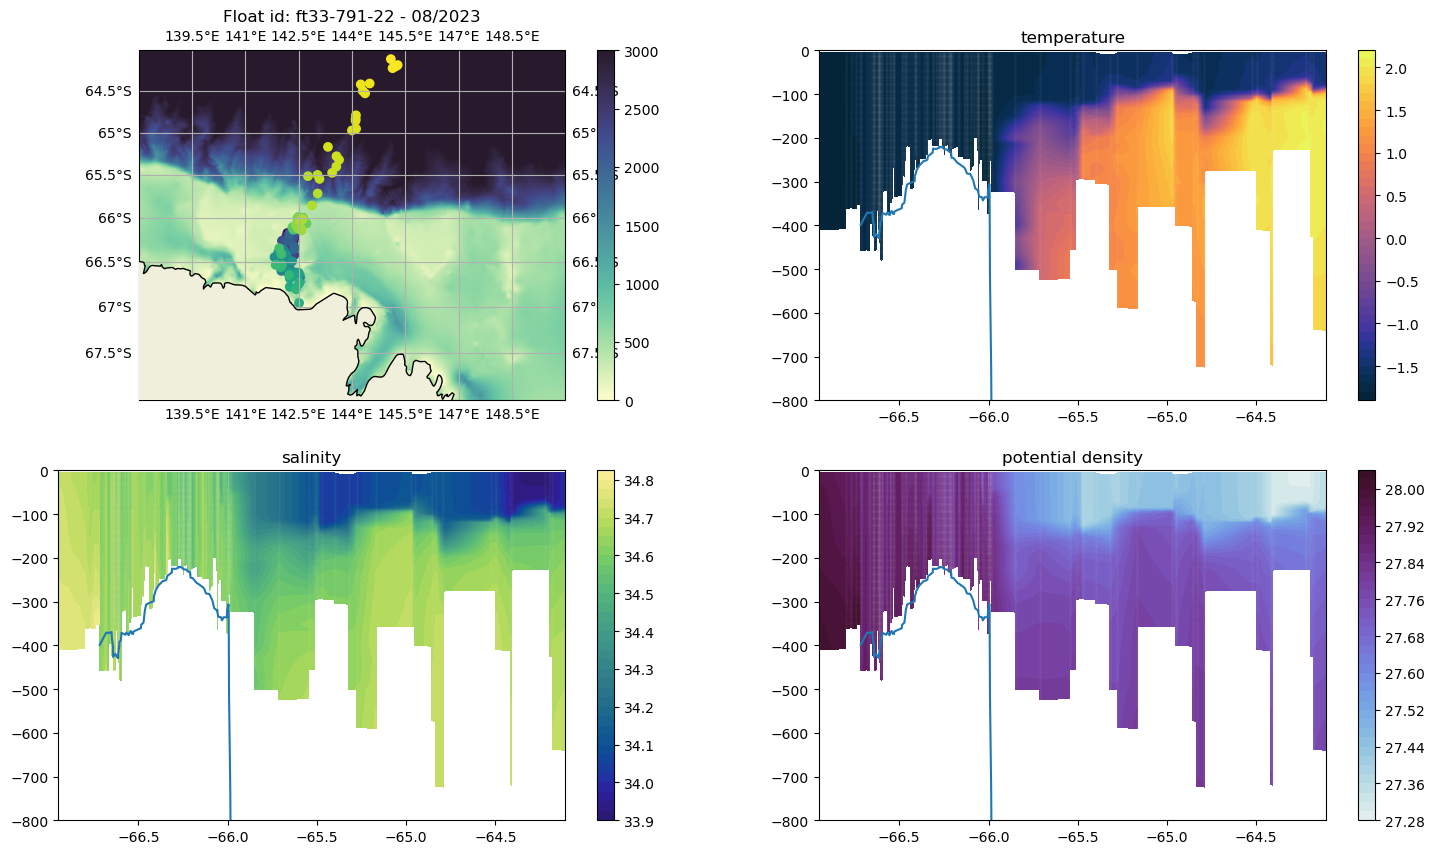

In [46]:

fig = plt.figure(figsize=(18,10))
gs = fig.add_gridspec(2,2)

et = elevation.interp({'latitude':dsml.lat,'longitude':dsml.lon}).rolling({'lat':10},center=True).mean()
minz = -800
levels = 40

ax = fig.add_subplot(gs[0, 0],projection=ccrs.Mercator())
im=pfns.sp(ax,-elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3,vmin=0,vmax=3000)
ax.scatter(dsm.lon,dsm.lat,c=dsm.time,transform=ccrs.PlateCarree(),label=pc)
plt.colorbar(im)
ax.set_title('Float id: ' + pc + ' - ' + dsm.time[0].dt.strftime("%m/%Y").item())

ax = fig.add_subplot(gs[0, 1])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.temp.T,cmap=cmocean.cm.thermal,levels=levels)#np.linspace(-1.8,0,levels),vmin=-1.8,vmax=0)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.001)
ax.set_title('temperature')

ax = fig.add_subplot(gs[1, 0])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.psal.T,cmap=cmocean.cm.haline,levels=levels)#,vmin=34.2,vmax=34.7)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.001)
ax.set_title('salinity')

ax = fig.add_subplot(gs[1, 1])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.sigma0.T,cmap=cmocean.cm.dense,levels=levels)#,vmin=27.5,vmax=28)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.001)
ax.set_title('potential density')

In [18]:
seasons

{'autumn': <xarray.Dataset> Size: 510kB
 Dimensions:    (time: 18, pres: 501)
 Coordinates:
   * time       (time) datetime64[ns] 144B 2007-04-01 2007-05-01 ... 2023-06-01
   * pres       (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
 Data variables:
     temp       (time, pres) float64 72kB nan nan nan -1.867 ... nan nan nan nan
     psal       (time, pres) float64 72kB nan nan nan 34.27 ... nan nan nan nan
     mld        (time) float64 144B 132.3 92.21 183.9 124.7 ... 71.65 nan nan nan
     asal       (time, pres) float64 72kB nan nan nan 34.44 ... nan nan nan nan
     ctemp      (time, pres) float64 72kB nan nan nan -1.864 ... nan nan nan nan
     rho        (time, pres) float64 72kB nan nan nan 1.028e+03 ... nan nan nan
     mlp        (time) float64 144B 123.9 82.53 166.7 118.4 ... 63.45 nan nan nan
     gph        (time, pres) float64 72kB nan nan nan nan nan ... nan nan nan nan
     elevation  (time) float64 144B -580.7 -323.3 -389.9 ... -222.6 -236.2 -686.1

In [54]:
s='summer'
data = seasons[s].where(seasons[s].elevation > -1000,drop=True)['temp']
data.where(data.count('time') > 10, drop=True)

<xarray.DataArray 'temp' (time: 1168, pres: 444)> Size: 4MB
array([[        nan, -1.33907974, -1.33425757, ...,         nan,
                nan,         nan],
       [        nan, -1.14503813, -1.12921158, ...,         nan,
                nan,         nan],
       [        nan, -1.60383403, -1.59307195, ...,         nan,
                nan,         nan],
       ...,
       [-1.32612157, -1.32687382, -1.32762607, ...,         nan,
                nan,         nan],
       [-1.52484989, -1.52339939, -1.52194889, ...,         nan,
                nan,         nan],
       [-1.31285846, -1.31151859, -1.31017872, ...,         nan,
                nan,         nan]], shape=(1168, 444))
Coordinates:
  * time     (time) datetime64[ns] 9kB 2007-02-20T23:29:59.000002 ... 2024-02...
    lon      (time) float64 9kB 140.0 140.0 140.0 140.0 ... 140.0 139.8 139.8
    lat      (time) float64 9kB -66.56 -66.58 -66.66 ... -66.65 -66.61 -66.61
    n_prof   (time) float64 9kB 7.932e+05 7.932e+05 7.932e+05 ... nan nan nan
  * pres     (pres) int64 4kB 4 6 8 10 12 14 16 ... 878 880 882 884 886 888 890

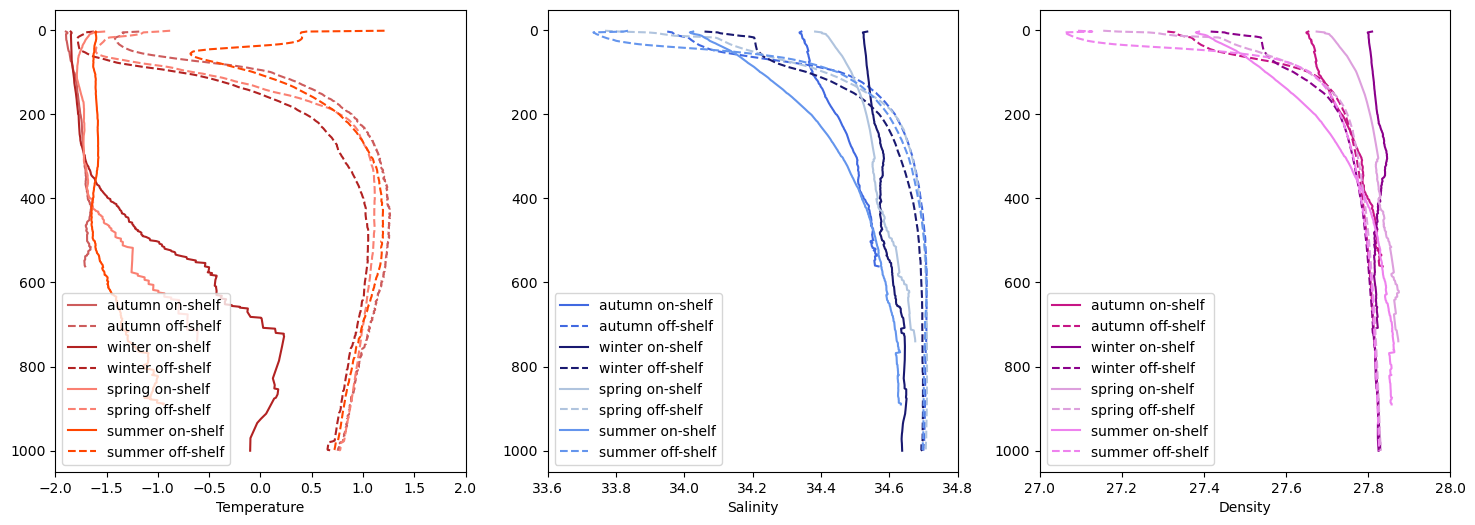

In [ ]:
# some example sections